# Personalized E-Learning Recommendation System

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Data Loading

In [2]:
try:
    df = pd.read_csv('Online_Courses.csv')
    print("Dataset loaded successfully. First 5 rows:")
    display(df.head())
except FileNotFoundError:
    print("Error: 'Online_Courses.csv' not found. Please upload the dataset to your Colab environment.")
    # Create a dummy DataFrame for demonstration if the file is not found
    df = pd.DataFrame({
        'course_title': ['Data Science Fundamentals', 'Python for Beginners', 'Machine Learning Basics', 'Web Development Masterclass', 'Advanced SQL'],
        'subject': ['Data Science', 'Programming', 'Data Science', 'Web Development', 'Database'],
        'level': ['Beginner', 'Beginner', 'Intermediate', 'Beginner', 'Intermediate'],
        'rating': [4.5, 4.2, 4.7, 4.0, 4.3],
        'skills_tags': ['Python, Statistics, ML', 'Python, Basics, Coding', 'Algorithms, Python, ML, Statistics', 'HTML, CSS, JavaScript, React', 'SQL, Database, Query']
    })
    print("Using dummy data for demonstration.")
    display(df.head())

Error: 'Online_Courses.csv' not found. Please upload the dataset to your Colab environment.
Using dummy data for demonstration.


,course_title,subject,level,rating,skills_tags
0,Data Science Fundamentals,Data Science,Beginner,4.5,"Python, Statistics, ML"
1,Python for Beginners,Programming,Beginner,4.2,"Python, Basics, Coding"
2,Machine Learning Basics,Data Science,Intermediate,4.7,"Algorithms, Python, ML, Statistics"
3,Web Development Masterclass,Web Development,Beginner,4.0,"HTML, CSS, JavaScript, React"
4,Advanced SQL,Database,Intermediate,4.3,"SQL, Database, Query"


## 3. Data Understanding

In [3]:
print(f"Dataset shape: {df.shape}")
print("\nColumn names:")
print(df.columns.tolist())
print("\nDataset info:")
df.info()
print("\nMissing values:")
display(df.isnull().sum().to_frame(name='missing_count'))

Dataset shape: (5, 5)

Column names:
['course_title', 'subject', 'level', 'rating', 'skills_tags']

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   course_title  5 non-null      object 
 1   subject       5 non-null      object 
 2   level         5 non-null      object 
 3   rating        5 non-null      float64
 4   skills_tags   5 non-null      object 
dtypes: float64(1), object(4)
memory usage: 332.0+ bytes

Missing values:


,missing_count
course_title,0
subject,0
level,0
rating,0
skills_tags,0


## 4. Data Preprocessing

In [4]:
# Handling missing values - filling with 'unknown' or empty string for text columns
for col in ['subject', 'level', 'skills_tags']:
    if col in df.columns:
        df[col] = df[col].fillna('')

# Converting text columns to lowercase and removing unnecessary spaces
text_cols = ['course_title', 'subject', 'level', 'skills_tags']
for col in text_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.lower().str.strip()

# Selecting useful columns
selected_columns = ['course_title', 'subject', 'level', 'rating', 'skills_tags']
df_processed = df[selected_columns].copy()

print("Data preprocessing complete. First 5 rows of processed data:")
display(df_processed.head())

Data preprocessing complete. First 5 rows of processed data:


,course_title,subject,level,rating,skills_tags
0,data science fundamentals,data science,beginner,4.5,"python, statistics, ml"
1,python for beginners,programming,beginner,4.2,"python, basics, coding"
2,machine learning basics,data science,intermediate,4.7,"algorithms, python, ml, statistics"
3,web development masterclass,web development,beginner,4.0,"html, css, javascript, react"
4,advanced sql,database,intermediate,4.3,"sql, database, query"


## 5. Feature Engineering

In [5]:
# Create a combined feature column
df_processed['combined_features'] = df_processed['subject'] + ' ' + \
                                   df_processed['level'] + ' ' + \
                                   df_processed['skills_tags']

# Use TF-IDF vectorization
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(df_processed['combined_features'])

print("Combined features created and TF-IDF vectorization complete. Shape of TF-IDF matrix:")
print(tfidf_matrix.shape)

Combined features created and TF-IDF vectorization complete. Shape of TF-IDF matrix:
(5, 20)


## 6. Content Based Recommendation Model

In [6]:
# Compute cosine similarity
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

print("Cosine similarity matrix computed.")

def recommend_courses(course_title_input, df=df_processed, cosine_sim_matrix=cosine_sim, top_n=5):

    # Get the index of the course that matches the title
    idx = df[df['course_title'] == course_title_input.lower().strip()].index

    if len(idx) == 0:
        print(f"Course '{course_title_input}' not found. Please check the title.")
        return pd.DataFrame()

    idx = idx[0]

    # Get the pairwise similarity scores with that course
    sim_scores = list(enumerate(cosine_sim_matrix[idx]))

    # Sort the courses based on the similarity scores
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # Get the scores of the top_n most similar courses. Exclude the input course itself.
    sim_scores = sim_scores[1:top_n+1]

    # Get the course indices
    course_indices = [i[0] for i in sim_scores]
    course_similarities = [i[1] for i in sim_scores]

    # Return the top N most similar courses
    recommended_df = df.iloc[course_indices][['course_title', 'subject', 'level', 'rating']].copy()
    recommended_df['similarity_score'] = course_similarities
    return recommended_df

Cosine similarity matrix computed.


## 7. Model Testing

In [7]:
example_course_title = df_processed['course_title'].iloc[0] # Pick the first course for testing

print(f"Recommending courses similar to: '{example_course_title.title()}'")
recommendations = recommend_courses(example_course_title)

if not recommendations.empty:
    display(recommendations)

Recommending courses similar to: 'Data Science Fundamentals'


,course_title,subject,level,rating,similarity_score
2,machine learning basics,data science,intermediate,4.7,0.752213
1,python for beginners,programming,beginner,4.2,0.242863
3,web development masterclass,web development,beginner,4.0,0.094399
4,advanced sql,database,intermediate,4.3,0.000000


## 8. Visualization

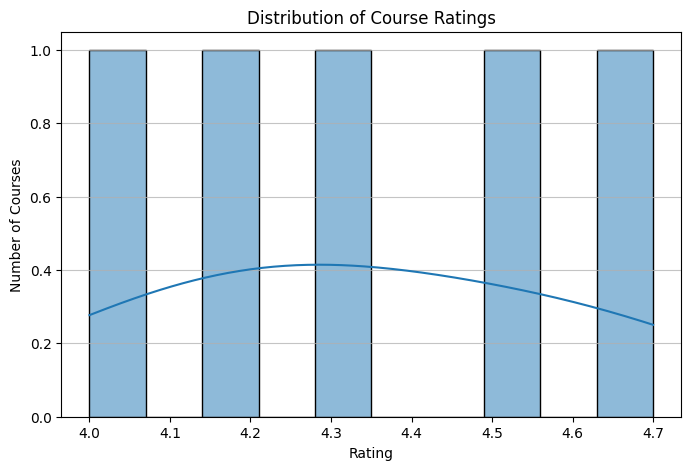

/tmp/ipykernel_1576/3387327530.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_processed['subject'], order=df_processed['subject'].value_counts().index, palette='viridis')


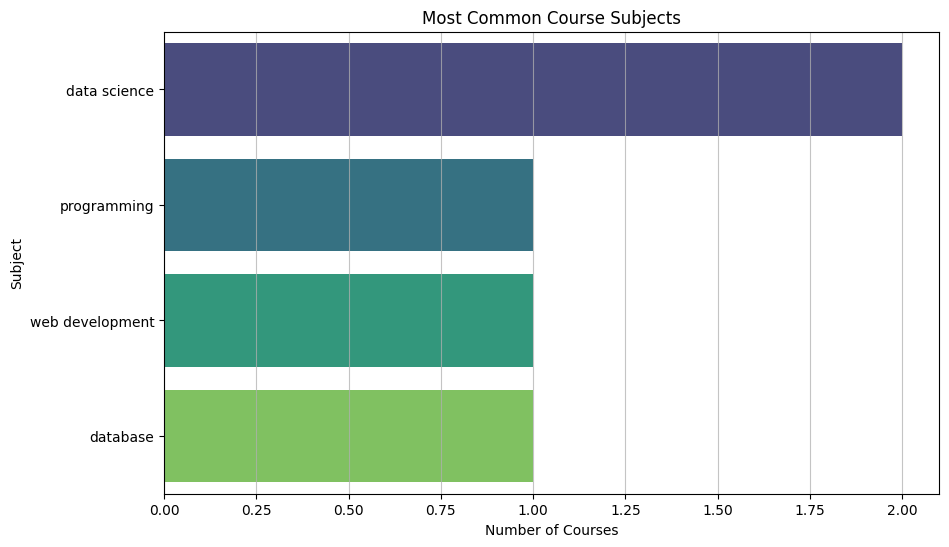

/tmp/ipykernel_1576/3387327530.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='rating', y='course_title', data=top_rated_courses, palette='magma')


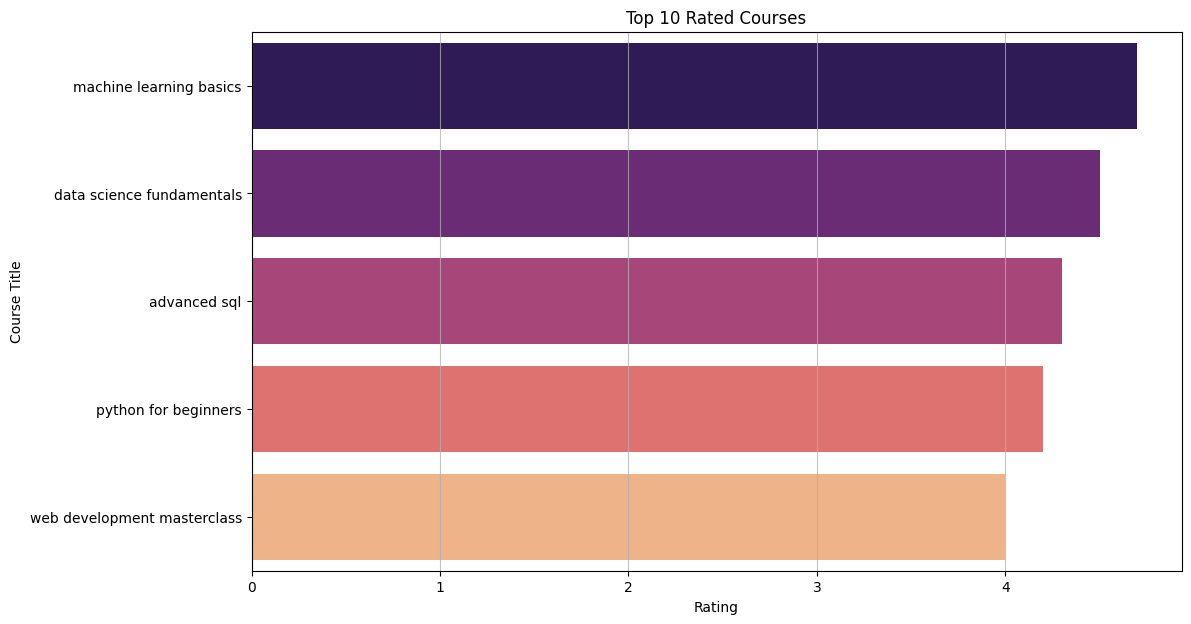

In [8]:
# Distribution of course ratings
plt.figure(figsize=(8, 5))
sns.histplot(df_processed['rating'], bins=10, kde=True)
plt.title('Distribution of Course Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Courses')
plt.grid(axis='y', alpha=0.75)
plt.show()

# Most common course subjects
plt.figure(figsize=(10, 6))
sns.countplot(y=df_processed['subject'], order=df_processed['subject'].value_counts().index, palette='viridis')
plt.title('Most Common Course Subjects')
plt.xlabel('Number of Courses')
plt.ylabel('Subject')
plt.grid(axis='x', alpha=0.75)
plt.show()

# Top rated courses (display top 10)
top_rated_courses = df_processed.sort_values(by='rating', ascending=False).drop_duplicates(subset='course_title').head(10)
plt.figure(figsize=(12, 7))
sns.barplot(x='rating', y='course_title', data=top_rated_courses, palette='magma')
plt.title('Top 10 Rated Courses')
plt.xlabel('Rating')
plt.ylabel('Course Title')
plt.grid(axis='x', alpha=0.75)
plt.show()

## 9. Evaluation

Evaluating recommendation systems often involves metrics like **Precision** and **Recall**.

*   **Precision** measures the proportion of recommended items that are relevant to the user. For example, if we recommend 5 courses and 3 are actually relevant to the user's interests, the precision is 3/5 = 0.6.

*   **Recall** measures the proportion of relevant items that are successfully recommended. For instance, if there are 10 courses relevant to a user and our system recommends 3 of them, the recall is 3/10 = 0.3.

Other metrics include F1-score (harmonic mean of precision and recall), Mean Average Precision (MAP), and Normalized Discounted Cumulative Gain (NDCG) for ranking-aware evaluation. However, for a simple content-based system without explicit user feedback data, these metrics are harder to calculate directly and often rely on user studies or proxy relevance data.

## 10. Conclusion

This project successfully demonstrates a basic content-based e-learning recommendation system. By leveraging TF-IDF and cosine similarity on combined course features, the system can identify and suggest courses similar to a given input. Future enhancements could include incorporating user interaction data for collaborative filtering or hybrid approaches, and more sophisticated natural language processing techniques for feature extraction.